In [1]:
import numpy as np
import pandas as pd
import pymannkendall as mk

water = pd.read_excel('../results/processed_data and results/water consumption.xlsx', index_col=0)
ab_rate = pd.read_excel('../results/processed_data and results/abandonment_rate.xlsx', index_col=0)
pro_pct = pd.read_excel('../results/processed_data and results/Production_Percent.xlsx', index_col=0)

# Historical (2000-2023) irrigation water use trend per state, via Sen's
# slope with Mann-Kendall significance -- matches Fig. 2d's caption: solid
# circles = significant at p<0.05, empty circles = not distinguishable
# from noise.
water = water[sorted(water.columns)]
water_trend = {}
water_significant = {}
for state in water.index:
    result = mk.original_test(water.loc[state].values.astype(float))
    water_trend[state] = result.slope
    water_significant[state] = result.p < 0.05
water_trend = pd.Series(water_trend)
water_significant = pd.Series(water_significant)

print(ab_rate)
print(water_trend)
print(pro_pct)


                    2023      2022      2021      2020      2019      2018  \
Category                                                                     
ALABAMA         0.010526  0.011494  0.009877  0.008889  0.014815  0.031373   
ARIZONA         0.010870  0.015686  0.009302  0.015209  0.011940  0.005731   
ARKANSAS        0.009804  0.023438  0.010417  0.009524  0.016129  0.010309   
CALIFORNIA      0.012245  0.011194  0.013158  0.008287  0.015504  0.007722   
FLORIDA         0.022472  0.028302  0.021739  0.051020  0.017857  0.205128   
GEORGIA         0.009009  0.015504  0.008547  0.008403  0.014286  0.097902   
KANSAS          0.139130  0.165644  0.072727  0.072539  0.152941  0.087500   
LOUISIANA       0.041667  0.025641  0.054545  0.029412  0.042857  0.030769   
MISSISSIPPI     0.012500  0.009434  0.033708  0.009434  0.014085  0.008065   
MISSOURI        0.014925  0.055556  0.015873  0.027119  0.031579  0.009231   
NEW MEXICO      0.220619  0.438824  0.214141  0.311927  0.274929

In [2]:
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = "Arial"

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] =8

[]


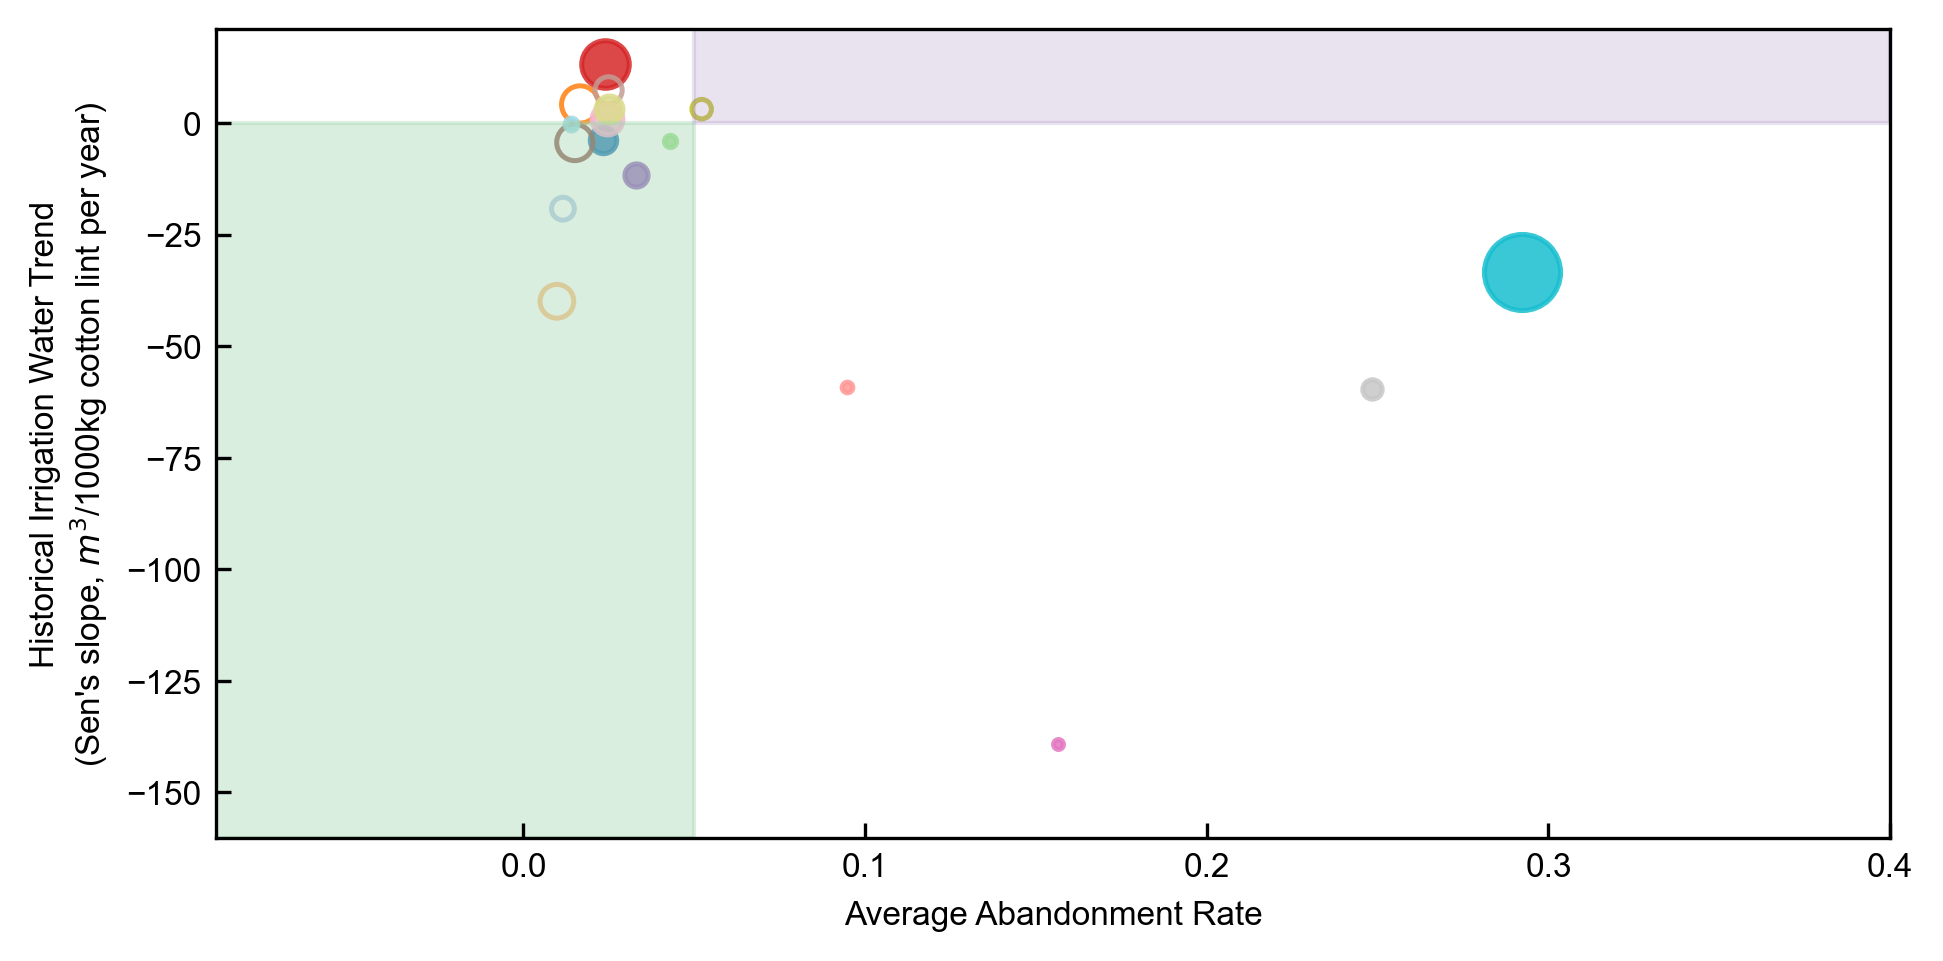

In [3]:
import numpy as np
import matplotlib.pyplot as plt

ab_average = ab_rate.mean(axis=1)
means = water_trend.reindex(ab_average.index)
sizes = pro_pct.mean(axis=0).reindex(ab_average.index)
significant = water_significant.reindex(ab_average.index)

colors = plt.cm.tab20(np.linspace(0, 1, len(ab_average)))

fig, ax = plt.subplots(figsize=(7.2, 3.5))
# Solid circles: Mann-Kendall trend significant at p<0.05.
# Empty circles: trend not distinguishable from noise.
for i, state in enumerate(ab_average.index):
    facecolor = colors[i] if significant.iloc[i] else 'none'
    ax.scatter(ab_average.iloc[i], means.iloc[i], s=sizes.iloc[i] * 1000,
               facecolors=facecolor, edgecolors=colors[i], linewidth=1.2, alpha=0.85)

plt.xlim([-0.09, 0.4])
y_lo, y_hi = means.min() * 1.15, means.max() * 1.6

plt.ylim([y_lo, y_hi])

plt.fill_betweenx(y=[y_lo, 0], x1=-0.09, x2=0.05, color='#A4D5B1', alpha=0.4)
plt.fill_betweenx(y=[0, y_hi], x1=0.05, x2=0.4, color='#A88EC0', alpha=0.25)

plt.xlabel('Average Abandonment Rate')
plt.ylabel("Historical Irrigation Water Trend\n(Sen's slope, $m^3$/1000kg cotton lint per year)")
plt.savefig('../outputs/strategy/figure_strategy.tiff', dpi=300, bbox_inches='tight')
plt.show()
